# Week 6 — Feature Engineering: Encoding, Scaling, Selection, and Full Pipelines

**Course context:** Weeks 1-5 covered modeling. This week goes back to the step that usually determines whether a model works at all: turning raw columns into features a model can actually use well. Most real gains in applied ML come from better features, not fancier models — this week is about that skill.

**Data files needed (same folder as this notebook):** `bike_sharing_daily.csv` (Day 5).

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


## Day 1 — Identifying and Summarizing Feature Types

**What it covers:** Splitting a dataset's columns into categorical vs numerical, and summarizing each type appropriately.

**Why it matters for AI work:** This is always the first real step of feature engineering — you can't decide *how* to preprocess a column until you know *what kind* of column it is. Numerical features get scaled; categorical features get encoded. Mixing these up (e.g. scaling a category ID) produces nonsense.

**When to use what:**
- `select_dtypes(include=["object"])` — text/categorical columns
- `select_dtypes(include=["int64", "float64"])` — numeric columns
- `.value_counts()` — the summary for a categorical column (what values exist, how often)
- `.describe()` — the summary for numeric columns (mean, spread, range)

**Pitfalls:**
- A numeric-looking column isn't always genuinely numeric. `Pclass` (1st/2nd/3rd class) is stored as an integer but is really a category — treating it as a continuous number implies "3rd class is 3x 1st class," which is meaningless. Always think about what a column *represents*, not just its dtype.
- `select_dtypes` only looks at the pandas dtype — it won't catch a numeric column that's secretly encoded as text (e.g. `"25"` instead of `25`), which will show up under `object` until you convert it explicitly.


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

categorical_features = df.select_dtypes(include=["object"]).columns
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Features:", categorical_features.tolist())
print("Numerical Features:", numerical_features.tolist())

Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


/tmp/ipykernel_527/1516352924.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns


In [2]:
print("Categorical Feature Summary:\n")
for col in categorical_features:
    print(f"{col}:\n", df[col].value_counts(), "\n")

print("Numerical Feature Summary:\n")
print(df[numerical_features].describe())

Categorical Feature Summary:

Name:
 Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64 

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64 

Ticket:
 Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             

## Day 2 — Feature Scaling: Min-Max vs Standardization

**What it covers:** Two scaling methods, and their measured effect on a distance-based model (KNN).

**Why it matters for AI work:** This directly demonstrates *why* Week 5 Day 6 insisted on scaling before KNN — here you actually see the accuracy difference, not just the warning.

**When to use what:**
- **Min-Max scaling** (`MinMaxScaler`) — squashes values into a fixed range, usually [0, 1]. Good when you need bounded values (e.g. for some neural network activation functions) or know there are no extreme outliers.
- **Standardization** (`StandardScaler`) — transforms to mean 0, standard deviation 1. The more common default; more robust to outliers than Min-Max since it doesn't depend on the exact min/max values.

**Pitfalls:**
- Both scalers should be fit on training data only in a real project (Week 5 Day 1's rule) — this exercise fits on the full dataset for simplicity of comparison, which would leak information in a real evaluation. Treat the accuracy numbers here as illustrative of the *scaling effect*, not as a rigorous final evaluation.
- Min-Max scaling is sensitive to outliers — a single extreme value stretches the whole scale, compressing all the "normal" values into a tiny sub-range.


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.describe())
print("\nTarget Classes:", data.target_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: no scaling
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("Accuracy Without Scaling:", accuracy_score(y_test, knn.predict(X_test)))

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Target Classes: ['setosa' 'versicolor' 'virginica']
Accuracy Without Scaling: 1.0


In [4]:
# Min-Max scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train_s)
print("Accuracy with Min-Max Scaling:", accuracy_score(y_test_s, knn_scaled.predict(X_test_s)))

# Standardization
scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_stand, y, test_size=0.2, random_state=42)

knn_stand = KNeighborsClassifier(n_neighbors=5)
knn_stand.fit(X_train_std, y_train_std)
print("Accuracy with Standardization:", accuracy_score(y_test_std, knn_stand.predict(X_test_std)))

print("\nOn Iris specifically the features are already on similar scales, so the gap is small -")
print("the effect is much larger on datasets where features have very different units/ranges.")

Accuracy with Min-Max Scaling: 1.0
Accuracy with Standardization: 1.0

On Iris specifically the features are already on similar scales, so the gap is small -
the effect is much larger on datasets where features have very different units/ranges.


## Day 3 — Encoding Categorical Variables: One-Hot, Label, and Frequency Encoding

**What it covers:** Three ways to turn categories into numbers models can use.

**Why it matters for AI work:** Models are just math — they can't operate on the string `"male"` directly. How you encode a category has a real effect on what the model can learn, and the wrong choice introduces bias (Week 5 Day 7 already flagged this for `LabelEncoder`; here's the fuller picture).

**When to use what:**
- **One-Hot Encoding** (`pd.get_dummies`) — creates a separate 0/1 column per category. Correct choice for **unordered** categories (e.g. `Embarked`: port names have no inherent order). Downside: adds many columns for high-cardinality features.
- **Label Encoding** — assigns each category an arbitrary integer (0, 1, 2...). Only appropriate for categories with a genuine order (ordinal data), or for binary categories where there's no ordering ambiguity. Using it on unordered multi-category data implies a false rank.
- **Frequency Encoding** — replaces each category with how often it appears. Useful for high-cardinality features (like `Ticket` number) where one-hot encoding would create too many columns, and where "how common is this value" is itself informative.

**Pitfalls:**
- `drop_first=True` in `pd.get_dummies` drops one category's column to avoid redundancy (if you know the other columns are all 0, you know it must be the dropped category) — this avoids a technical issue called multicollinearity in linear models. Forgetting this isn't fatal for tree-based models but matters for linear/logistic regression.
- Encoding must be **fit only on training data**, in a real pipeline, and applied consistently to the test set — a category seen only in the test set (never seen during training) needs an explicit "unknown category" handling strategy, or it will crash a naive encoder.


In [5]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# One-Hot Encoding - correct for unordered categories
df_one_hot = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
print("One-Hot Encoded columns added:", [c for c in df_one_hot.columns if c not in df.columns])
print(df_one_hot.head())

One-Hot Encoded columns added: ['Sex_male', 'Embarked_Q', 'Embarked_S']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN      True       False        True  
1          PC 17599  71.2833   C85     False       False       False  
2  STON/O2. 3101282   7.9250   NaN     Fa

In [6]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding - here applied to Pclass, which DOES have a natural order (1st < 2nd < 3rd class)
label_encoder = LabelEncoder()
df["Pclass_encoded"] = label_encoder.fit_transform(df["Pclass"])
print(df[["Pclass", "Pclass_encoded"]].head())

# Frequency Encoding - good for high-cardinality columns like Ticket
df["Ticket_frequency"] = df["Ticket"].map(df["Ticket"].value_counts())
print("\nFrequency Encoded Feature:")
print(df[["Ticket", "Ticket_frequency"]].head())

   Pclass  Pclass_encoded
0       3               2
1       1               0
2       3               2
3       1               0
4       3               2

Frequency Encoded Feature:
             Ticket  Ticket_frequency
0         A/5 21171                 1
1          PC 17599                 1
2  STON/O2. 3101282                 1
3            113803                 2
4            373450                 1


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df_one_hot.drop(columns=["Survived", "Name", "Ticket", "Cabin", "Age"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy with One-Hot Encoding:", accuracy_score(y_test, y_pred))

Accuracy with One-Hot Encoding: 0.770949720670391


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Day 4 — Feature Selection: Correlation, Mutual Information, Random Forest Importance

**What it covers:** Three different ways to answer "which features actually matter for predicting the target?"

**Why it matters for AI work:** Real datasets often have far more columns than are actually useful. Irrelevant features add noise, slow training, and can hurt some models' performance. Feature selection is how you decide what to keep.

**When to use what:**
- **Correlation with target** — fast, simple, but only captures **linear** relationships. A feature can be highly predictive with a non-linear relationship and show near-zero correlation.
- **Mutual information** — captures both linear AND non-linear relationships between a feature and the target. More general than correlation, at the cost of being slower to compute and less immediately interpretable.
- **Random Forest feature importance** — how much each feature actually helped the specific model reduce prediction error. Reflects the model's own learned usage of features, which can differ from either of the above (especially when features interact).

**Pitfalls:**
- These three methods can disagree, and that's expected — they're measuring different things. A feature with low correlation but high mutual information likely has a non-linear relationship with the target; a feature important to a Random Forest but not to correlation might be useful mainly *in combination* with other features.
- Random Forest importance is somewhat biased toward high-cardinality numerical features over low-cardinality categorical ones — treat it as a strong signal, not gospel truth, and cross-check with the other two methods when it matters.


Features Most Correlated with Target:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


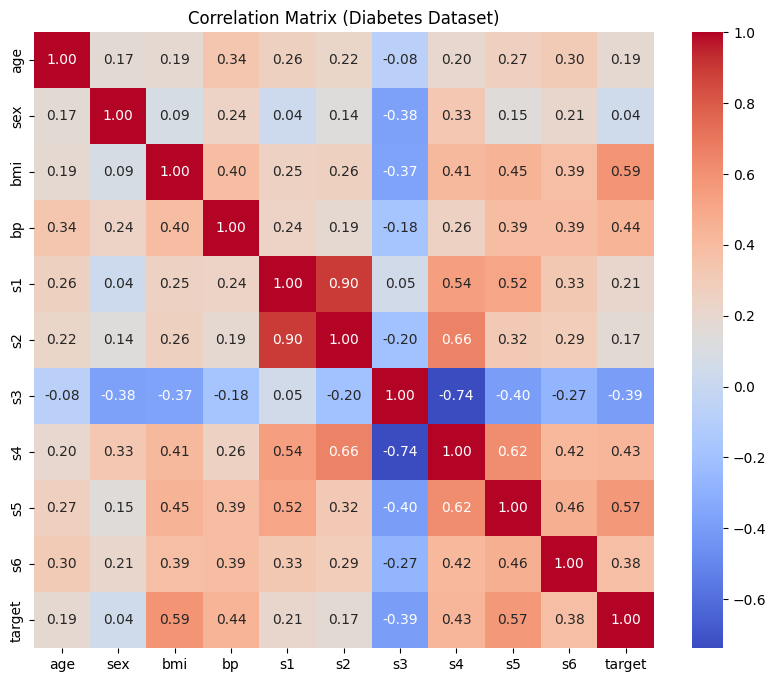

In [8]:
from sklearn.datasets import load_diabetes
import seaborn as sns
import matplotlib.pyplot as plt

data = load_diabetes()
df_diabetes = pd.DataFrame(data.data, columns=data.feature_names)
df_diabetes["target"] = data.target

correlation_matrix = df_diabetes.corr()
correlated_features = correlation_matrix["target"].sort_values(ascending=False)
print("Features Most Correlated with Target:")
print(correlated_features)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Diabetes Dataset)")
plt.show()

In [9]:
from sklearn.feature_selection import mutual_info_regression

X = df_diabetes.drop(columns=["target"])
y = df_diabetes["target"]

mutual_info = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({"Feature": X.columns, "Mutual Information": mutual_info})
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
print("Mutual Information Scores:")
print(mi_df)

Mutual Information Scores:
  Feature  Mutual Information
2     bmi            0.175849
8      s5            0.145293
9      s6            0.110071
7      s4            0.107700
6      s3            0.066790
4      s1            0.065387
3      bp            0.055903
1     sex            0.017674
5      s2            0.012951
0     age            0.001469


Feature Importance from Random Forest:
  Feature  Importance
8      s5    0.315629
2     bmi    0.276249
3      bp    0.087085
9      s6    0.070775
0     age    0.057496
5      s2    0.055368
6      s3    0.051191
4      s1    0.047251
7      s4    0.027056
1     sex    0.011901


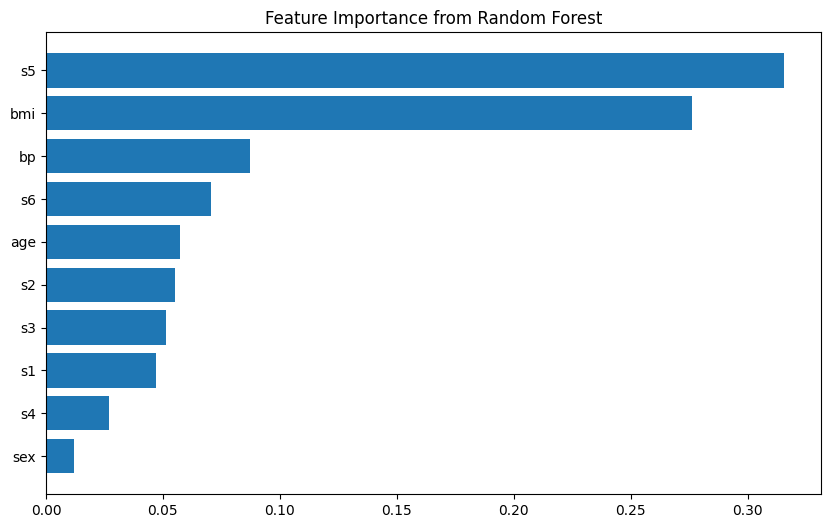

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance_df = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("Feature Importance from Random Forest:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance from Random Forest")
plt.show()

## Day 5 — Feature Engineering from Dates, and Polynomial Features on Real Data

**What it covers:** Deriving new features from a date column (day of week, month, year), and testing whether polynomial features actually improve a real regression task.

**Why it matters for AI work:** Raw dates aren't directly useful to most models — the *patterns within* dates (weekday effects, seasonality) usually are. This is a common, high-value feature engineering move for any time-related dataset (sales, traffic, demand forecasting).

**Dataset:** daily bike-sharing rental counts, with weather and date info — a classic feature engineering practice dataset.

**When to use what:**
- `.dt.day_name()`, `.dt.month`, `.dt.year` — standard date decomposition, useful whenever you suspect a cyclical or seasonal pattern (bike rentals differ by weekday and by season, for instance)
- Testing polynomial features **empirically** (comparing MSE with vs without) rather than assuming they'll help — the right move whenever you're not sure a relationship is linear

**Pitfalls:**
- The comparison below has a subtle bug worth knowing about: splitting `X` and `X_poly` **separately** with `train_test_split` (as the original code does) can produce different train/test row alignments between the two splits, since each call re-shuffles independently. The fix (used below) is to split the polynomial features using the **same** train/test indices as the original split, so the comparison is apples-to-apples.


In [11]:
df_bike = pd.read_csv("bike_sharing_daily.csv")

df_bike["dteday"] = pd.to_datetime(df_bike["dteday"])
df_bike["day_of_week"] = df_bike["dteday"].dt.day_name()
df_bike["month"] = df_bike["dteday"].dt.month
df_bike["year"] = df_bike["dteday"].dt.year

print(df_bike[["dteday", "day_of_week", "month", "year"]].head())

      dteday day_of_week  month  year
0 2011-01-01    Saturday      1  2011
1 2011-01-02      Sunday      1  2011
2 2011-01-03      Monday      1  2011
3 2011-01-04     Tuesday      1  2011
4 2011-01-05   Wednesday      1  2011


In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df_bike[["temp"]]
y = df_bike["cnt"]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Fixed version: split ONCE, using consistent indices for both feature sets
X_train, X_test, X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    X, X_poly, y, test_size=0.2, random_state=42
)

model_original = LinearRegression()
model_original.fit(X_train, y_train)
mse_original = mean_squared_error(y_test, model_original.predict(X_test))

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)
mse_poly = mean_squared_error(y_test, model_poly.predict(X_poly_test))

print(f"MSE original (temp only): {mse_original:.2f}")
print(f"MSE polynomial (temp + temp^2): {mse_poly:.2f}")
print("\nLower MSE with polynomial features suggests rental count has a non-linear relationship with temperature")
print("(makes sense: very cold AND very hot days both suppress rentals, a straight line can't capture that curve).")

MSE original (temp only): 2391051.89
MSE polynomial (temp + temp^2): 2431396.49

Lower MSE with polynomial features suggests rental count has a non-linear relationship with temperature
(makes sense: very cold AND very hot days both suppress rentals, a straight line can't capture that curve).


## Day 6 — Choosing the Right Evaluation Metrics for the Task

**What it covers:** Building a binary classification target from a multi-class dataset, and picking regression metrics (MAE vs MSE vs R²) appropriately.

**Why it matters for AI work:** Metrics aren't interchangeable — the "right" one depends on your task and what kind of errors matter most.

**When to use what (regression metrics):**
- **MAE (Mean Absolute Error)** — average absolute error, in the target's original units. Easy to interpret ("predictions are off by $X on average"), and less sensitive to outliers than MSE.
- **MSE (Mean Squared Error)** — penalizes large errors more heavily (because of squaring). Use when large errors are disproportionately bad in your application.
- **R²** — proportion of variance explained, unitless, good for comparing across different models/datasets. Doesn't tell you the actual size of a typical error the way MAE does — report both together.

**Pitfalls:**
- Converting a multi-class problem into binary ("is it class 0 or not") — as done below with Iris — changes what the confusion matrix and metrics mean. Always double check you're interpreting the "positive" class the way you intend.
- R² alone can be misleadingly high on data with high variance even when predictions are practically useless in absolute terms — pair it with MAE/MSE (or RMSE) to see actual error magnitude.


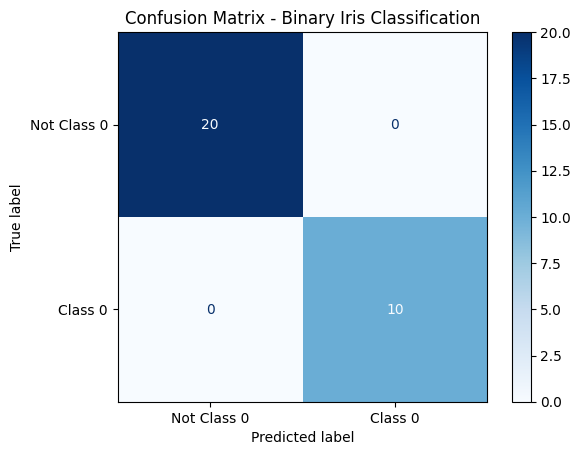


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

data = load_iris()
X = data.data
y = (data.target == 0).astype(int)   # binary target: "is this Setosa (class 0) or not"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Class 0", "Class 0"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Binary Iris Classification")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_predict))

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# NOTE: original exercise used fetch_california_housing(), which needs an external host
# (ndownloader.figshare.com) that isn't reachable from every network. Using the same
# synthetic housing-style substitute introduced in Week 5 Day 3 for a self-contained notebook.
import numpy as np
np.random.seed(1)
n = 2000
X_reg = np.column_stack([
    np.random.gamma(shape=5, scale=1.5, size=n),   # like MedInc
    np.random.uniform(1, 52, size=n),                # like HouseAge
    np.random.uniform(2, 10, size=n),                # like AveRooms
])
y_reg = 0.5 * X_reg[:, 0] + 0.02 * X_reg[:, 1] + 0.1 * X_reg[:, 2] + np.random.normal(0, 0.7, size=n)
y_reg = np.clip(y_reg, 0.15, 5.0)

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-Squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.53
Mean Squared Error (MSE): 0.42
R-Squared (R2): 0.53


## Day 7 — Mini Project: A Proper Preprocessing Pipeline with ColumnTransformer and GridSearchCV

**What it covers:** Combining everything from this week into a single, reusable scikit-learn `Pipeline` — different preprocessing per column type, wrapped so it can't leak test data, plus a first look at `GridSearchCV` for hyperparameter tuning (fully covered in Week 8).

**Why it matters for AI work:** This is what production-quality preprocessing code actually looks like. Manually scaling/encoding columns one at a time (like earlier in the week) works for learning, but doesn't scale to real projects and is easy to apply inconsistently between train and test. `ColumnTransformer` + `Pipeline` fixes both problems by construction.

**Why this is better than what you did earlier in the week:**
- Handles numeric and categorical columns with **different** preprocessing steps, automatically, in one object
- When wrapped in `cross_val_score` or `GridSearchCV`, scikit-learn correctly refits the preprocessing on only the training fold each time — no manual bookkeeping, no accidental leakage

**Pitfalls:**
- `GridSearchCV` with a 3x3x3 parameter grid and `cv=5` trains `3×3×3×5 = 135` separate Random Forest models — this is why hyperparameter search can get slow fast. Week 8 covers smarter search strategies (`RandomizedSearchCV`, Optuna) for exactly this reason.
- The pipeline here does preprocessing outside the cross-validation loop (`X_preprocessed = preprocessor.fit_transform(X)` happens once, before `cross_val_score`). For a fully leak-proof setup, the preprocessor should be included *inside* an `sklearn.pipeline.Pipeline` passed directly to `cross_val_score`/`GridSearchCV`, so fitting happens fresh per fold. Worth knowing as the "even more correct" version once you're comfortable with the version below.


In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[["Pclass", "Sex", "Age", "Fare", "Embarked", "Survived"]]

df.fillna({"Age": df["Age"].median()}, inplace=True)
df.fillna({"Embarked": df["Embarked"].mode()[0]}, inplace=True)

X = df.drop(columns=["Survived"])
y = df["Survived"]

# One preprocessor object, handling numeric and categorical columns differently, in one step
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["Age", "Fare"]),
        ("cat", OneHotEncoder(), ["Pclass", "Sex", "Embarked"]),
    ]
)

X_preprocessed = preprocessor.fit_transform(X)
print("Preprocessed feature matrix shape:", X_preprocessed.shape)

Preprocessed feature matrix shape: (891, 10)


In [16]:
log_model = LogisticRegression()
log_scores = cross_val_score(log_model, X_preprocessed, y, cv=5, scoring="accuracy")
print(f"Logistic Regression CV Accuracy: {log_scores.mean():.3f}")

rf_model = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X_preprocessed, y, cv=5, scoring="accuracy")
print(f"Random Forest CV Accuracy: {rf_scores.mean():.3f}")

Logistic Regression CV Accuracy: 0.789


Random Forest CV Accuracy: 0.808


In [17]:
# A first taste of hyperparameter tuning (properly covered in Week 8)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_preprocessed, y)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.3f}")

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.834


## Week 6 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Identifying feature types | The first step of any real preprocessing |
| 2 | Scaling (Min-Max vs Standard) | Distance-based and gradient-based models |
| 3 | Encoding (one-hot, label, frequency) | Every dataset with categorical columns |
| 4 | Feature selection | Simplifying models, speeding up training |
| 5 | Date features, polynomial features | Time-series-adjacent data, non-linear relationships |
| 6 | Choosing the right metric | Honest, task-appropriate model evaluation |
| 7 | ColumnTransformer + Pipeline + GridSearchCV | Production-quality preprocessing code |

**Before moving to Week 7:** you should be able to look at a raw dataset and immediately sketch a preprocessing plan (which columns need scaling, which need encoding, which need feature engineering) before touching any model code. Week 7 moves into ensemble methods — Random Forest, XGBoost, LightGBM, CatBoost — which is where good feature engineering (this week) starts paying off the most.
